In [1]:
import os
import glob
import time
import numpy as np
from glob import glob

import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.image import ssim
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

class CFG:
    BATCH_SIZE = 1       
    BUFFER_SIZE = 200
    LAMBDA = 10
    LR = 0.0002
    SEED = 7

set_seed(CFG.SEED)

In [3]:
try:
    tf.keras.mixed_precision.set_global_policy("float32")
    USE_MIXED = True
    print("Mixed precision enabled")
except Exception:
    USE_MIXED = False
    print("Mixed precision NOT enabled")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            pass

Mixed precision enabled


In [4]:
day_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Day"
night_dir = r"C:\DATA SEKUNDER\Resized 256 x 256\Night"

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (256, 256))
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    return img

def make_dataset(path):
    files = glob(path + "/*.jpg")
    ds = tf.data.Dataset.from_tensor_slices(files)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(CFG.BUFFER_SIZE).repeat()
    ds = ds.batch(CFG.BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

def show_sample(dataset, idx=0, title=None):
    batch = next(iter(dataset))
    img = batch[idx]
    img = tf.cast(img, tf.float32)
    img = (img * 0.5) + 0.5
    plt.figure(figsize=(8, 8))
    plt.imshow(img.numpy())
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

Day = make_dataset(day_dir)
Night = make_dataset(night_dir)

Train = tf.data.Dataset.zip((Day, Night))

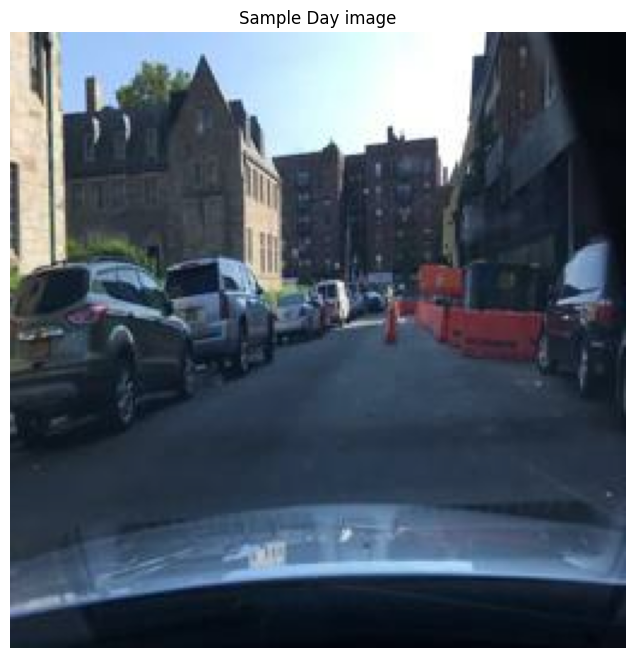

In [5]:
show_sample(Day, title='Sample Day image')

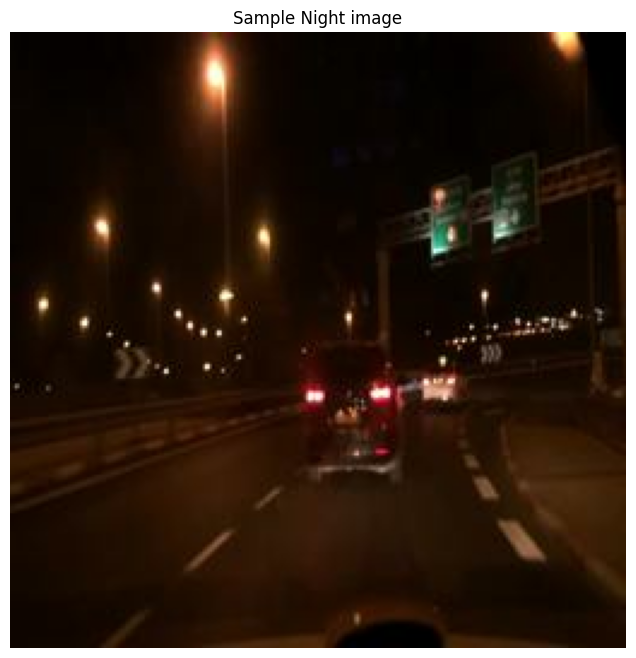

In [6]:
show_sample(Night, title='Sample Night image')

In [7]:
initializer = tf.random_normal_initializer(0., 0.02)

def resblock(x, filters):
    y = tf.keras.layers.Conv2D(filters, 3, padding="same",kernel_initializer=initializer, use_bias=False)(x)
    y = tfa.layers.InstanceNormalization()(y)
    y = tf.keras.layers.ReLU()(y)
    y = tf.keras.layers.Conv2D(filters, 3, padding="same",kernel_initializer=initializer, use_bias=False)(y)
    y = tfa.layers.InstanceNormalization()(y)
    return tf.keras.layers.Add()([x, y])

In [8]:
def build_generator():
    inputs = tf.keras.Input((256, 256, 3))

    # ---------------- Encoder ----------------
    x1 = tf.keras.layers.Conv2D(32, 7, padding="same",kernel_initializer=initializer, use_bias=False)(inputs)
    x1 = tfa.layers.InstanceNormalization()(x1)
    x1 = tf.keras.layers.ReLU()(x1)

    x2 = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(x1)
    x2 = tfa.layers.InstanceNormalization()(x2)
    x2 = tf.keras.layers.ReLU()(x2)

    x3 = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(x2)
    x3 = tfa.layers.InstanceNormalization()(x3)
    x3 = tf.keras.layers.ReLU()(x3)

    # ---------------- Bottleneck ----------------
    b = resblock(x3, 128)
    b = resblock(b, 128)

    # ---------------- Decoder + Skip ----------------
    u1 = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(b)
    u1 = tfa.layers.InstanceNormalization()(u1)
    u1 = tf.keras.layers.ReLU()(u1)

    u1 = tf.keras.layers.Concatenate()([u1, x2])

    u2 = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding="same",kernel_initializer=initializer, use_bias=False)(u1)
    u2 = tfa.layers.InstanceNormalization()(u2)
    u2 = tf.keras.layers.ReLU()(u2)

    u2 = tf.keras.layers.Concatenate()([u2, x1])

    out = tf.keras.layers.Conv2D(3, 7, padding="same",activation="tanh",kernel_initializer=initializer)(u2)

    return tf.keras.Model(inputs, out)

In [10]:
def build_discriminator():
    inp = tf.keras.Input((256, 256, 3))

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding="same",kernel_initializer=initializer)(inp)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(256, 4, strides=2, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    
    # Tambahan penting PatchGAN (stride=1)
    x = tf.keras.layers.Conv2D(256, 4, strides=1, padding="same",kernel_initializer=initializer)(x)
    x = tfa.layers.InstanceNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    # Output patch map
    out = tf.keras.layers.Conv2D(1, 4, strides=1, padding="same",kernel_initializer=initializer)(x)

    # out = tf.keras.layers.Conv2D(1, 4, padding="same",kernel_initializer=initializer)(x)
    return tf.keras.Model(inp, out)

In [47]:
print("\n==============================")
print("   MODEL SUMMARY GENERATOR")
print("==============================\n")

generator = build_generator()
generator.summary()


   MODEL SUMMARY GENERATOR

Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_271 (Conv2D)            (None, 256, 256, 32  4704        ['input_16[0][0]']               
                                )                                                                 
                                                                                                  
 instance_normalization_75 (Ins  (None, 256, 256, 32  64         ['conv2d_271[0][0]']             
 tanceNormalization)            )                             

In [55]:
print("\n==============================")
print("        LAYER GENERATOR")
print("==============================\n")

for i, layer in enumerate(generator.layers):
    print(
        f"{i:03d} | {layer.name:30s} "
        f"| shape : {layer.output_shape} "
        f"| params : {layer.count_params()}"
    )


        LAYER GENERATOR

000 | input_16                       | shape : [(None, 256, 256, 3)] | params : 0
001 | conv2d_271                     | shape : (None, 256, 256, 32) | params : 4704
002 | instance_normalization_75      | shape : (None, 256, 256, 32) | params : 64
003 | re_lu_42                       | shape : (None, 256, 256, 32) | params : 0
004 | conv2d_272                     | shape : (None, 128, 128, 64) | params : 18432
005 | instance_normalization_76      | shape : (None, 128, 128, 64) | params : 128
006 | re_lu_43                       | shape : (None, 128, 128, 64) | params : 0
007 | conv2d_273                     | shape : (None, 64, 64, 128) | params : 73728
008 | instance_normalization_77      | shape : (None, 64, 64, 128) | params : 256
009 | re_lu_44                       | shape : (None, 64, 64, 128) | params : 0
010 | conv2d_274                     | shape : (None, 64, 64, 128) | params : 147456
011 | instance_normalization_78      | shape : (None, 64, 64, 128

In [46]:
print("\n=============================")
print(" MODEL SUMMARY DISCRIMINATOR")
print("=============================\n")

discriminator = build_discriminator()
discriminator.summary()


 MODEL SUMMARY DISCRIMINATOR

Model: "model_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_15 (InputLayer)       [(None, 256, 256, 3)]     0         
                                                                 
 conv2d_266 (Conv2D)         (None, 128, 128, 64)      3136      
                                                                 
 leaky_re_lu_24 (LeakyReLU)  (None, 128, 128, 64)      0         
                                                                 
 conv2d_267 (Conv2D)         (None, 64, 64, 128)       131200    
                                                                 
 instance_normalization_72 (  (None, 64, 64, 128)      256       
 InstanceNormalization)                                          
                                                                 
 leaky_re_lu_25 (LeakyReLU)  (None, 64, 64, 128)       0         
                           

In [54]:
print("\n==============================")
print("     LAYER DISCRIMINATOR")
print("==============================\n")

for i, layer in enumerate(discriminator.layers):
    print(
        f"{i:03d} | {layer.name:30s} "
        f"| shape : {layer.output_shape} "
        f"| params : {layer.count_params()}"
    )


     LAYER DISCRIMINATOR

000 | input_15                       | shape : [(None, 256, 256, 3)] | params : 0
001 | conv2d_266                     | shape : (None, 128, 128, 64) | params : 3136
002 | leaky_re_lu_24                 | shape : (None, 128, 128, 64) | params : 0
003 | conv2d_267                     | shape : (None, 64, 64, 128) | params : 131200
004 | instance_normalization_72      | shape : (None, 64, 64, 128) | params : 256
005 | leaky_re_lu_25                 | shape : (None, 64, 64, 128) | params : 0
006 | conv2d_268                     | shape : (None, 32, 32, 256) | params : 524544
007 | instance_normalization_73      | shape : (None, 32, 32, 256) | params : 512
008 | leaky_re_lu_26                 | shape : (None, 32, 32, 256) | params : 0
009 | conv2d_269                     | shape : (None, 32, 32, 256) | params : 1048832
010 | instance_normalization_74      | shape : (None, 32, 32, 256) | params : 512
011 | leaky_re_lu_27                 | shape : (None, 32, 32, 25

In [12]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def disc_loss(real, fake):
    real = tf.cast(real, tf.float32)
    fake = tf.cast(fake, tf.float32)
    return 0.5 * (bce(tf.ones_like(real), real) + bce(tf.zeros_like(fake), fake))

def gen_loss(fake):
    fake = tf.cast(fake, tf.float32)
    return bce(tf.ones_like(fake), fake)

def cycle_loss(real, cycled):
    real = tf.cast(real, tf.float32)
    cycled = tf.cast(cycled, tf.float32)
    return CFG.LAMBDA * tf.reduce_mean(tf.abs(real - cycled))

def identity_loss(real, same):
    real = tf.cast(real, tf.float32)
    same = tf.cast(same, tf.float32)
    return CFG.LAMBDA * 0.5 * tf.reduce_mean(tf.abs(real - same))

In [13]:
class CycleGAN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.Gd2n = build_generator()   # Day → Night
        self.Gn2d = build_generator()   # Night → Day
        self.Dn   = build_discriminator()  # Discriminator Night
        self.Dd   = build_discriminator()  # Discriminator Day

    def compile(self, opt):
        super().compile()
        self.opt_g = opt
        self.opt_d = opt

    def train_step(self, batch):
        day, night = batch

        with tf.GradientTape(persistent=True) as tape:
            # =============================================
            #           Generator Forward Pass
            # =============================================
            fake_night   = self.Gd2n(day)
            cycled_day   = self.Gn2d(fake_night)

            fake_day     = self.Gn2d(night)
            cycled_night = self.Gd2n(fake_day)

            same_day   = self.Gn2d(day)
            same_night = self.Gd2n(night)

            # =============================================
            #         Discriminator Forward Pass
            # =============================================
            disc_real_n = self.Dn(night)
            disc_fake_n = self.Dn(fake_night)

            disc_real_d = self.Dd(day)
            disc_fake_d = self.Dd(fake_day)

            # =============================================
            #               Generator Losses
            # =============================================
            gl_d2n = gen_loss(disc_fake_n)
            gl_n2d = gen_loss(disc_fake_d)

            cyc = cycle_loss(day, cycled_day) + cycle_loss(night, cycled_night)
            idn = identity_loss(day, same_day) + identity_loss(night, same_night)

            total_g = gl_d2n + gl_n2d + cyc + idn

            # =============================================
            #             Discriminator Losses
            # =============================================
            dl_n    = disc_loss(disc_real_n, disc_fake_n)
            dl_d    = disc_loss(disc_real_d, disc_fake_d)
            total_d = dl_n + dl_d

        # =============================================
        #               Backpropagation
        # =============================================
        g_vars = self.Gd2n.trainable_variables + self.Gn2d.trainable_variables
        d_vars = self.Dn.trainable_variables + self.Dd.trainable_variables

        self.opt_g.apply_gradients(zip(tape.gradient(total_g, g_vars), g_vars))
        self.opt_d.apply_gradients(zip(tape.gradient(total_d, d_vars), d_vars))

        # =============================================
        #              Accuracy Metrics
        # =============================================
        # Convert logits to probabilities
        real_n_prob = tf.sigmoid(disc_real_n)
        fake_n_prob = tf.sigmoid(disc_fake_n)
        real_d_prob = tf.sigmoid(disc_real_d)
        fake_d_prob = tf.sigmoid(disc_fake_d)

        # Discriminator accuracy (real > 0.5, fake < 0.5)
        d_acc_real = 0.5 * (
            tf.reduce_mean(tf.cast(real_n_prob > 0.5, tf.float32)) +
            tf.reduce_mean(tf.cast(real_d_prob > 0.5, tf.float32))
        )
        d_acc_fake = 0.5 * (
            tf.reduce_mean(tf.cast(fake_n_prob < 0.5, tf.float32)) +
            tf.reduce_mean(tf.cast(fake_d_prob < 0.5, tf.float32))
        )
        d_acc = 0.5 * (d_acc_real + d_acc_fake)

        # Generator accuracy (wants fake images classified as real > 0.5)
        g_acc_n = tf.reduce_mean(tf.cast(fake_n_prob > 0.5, tf.float32))
        g_acc_d = tf.reduce_mean(tf.cast(fake_d_prob > 0.5, tf.float32))
        g_acc   = 0.5 * (g_acc_n + g_acc_d)

        return {
            "g_loss": total_g,
            "d_loss": total_d,
            "g_acc" : g_acc,
            "d_acc" : d_acc
        }

In [14]:
class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.g_losses = []
        self.d_losses = []
        self.g_accs  = []
        self.d_accs  = []

    def on_epoch_end(self, epoch, logs=None):
        self.g_losses.append(logs.get("g_loss"))
        self.d_losses.append(logs.get("d_loss"))
        self.g_accs.append(logs.get("g_acc"))
        self.d_accs.append(logs.get("d_acc"))

In [15]:
# Initialize model and optimizer
gan = CycleGAN()
optimizer = tf.keras.optimizers.Adam(CFG.LR, beta_1=0.5)
loss_history = LossHistory()

gan.compile(optimizer)

EPOCHS = 50
steps = 300

# Start timer
start_time = time.time()

# Training
gan.fit(Train,epochs=EPOCHS,steps_per_epoch=steps,callbacks=[loss_history])

# End timer
end_time = time.time()
total_seconds = end_time - start_time

# Convert to hours, minutes, seconds
hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

print(f"{hours} Hours {minutes} Minutes {seconds} Seconds")

Epoch 1/5
300/300 [==============================] - 317s 976ms/step - g_loss: 6.7622 - d_loss: 1.1573 - g_acc: 0.2764 - d_acc: 0.7265
Epoch 2/5
300/300 [==============================] - 292s 974ms/step - g_loss: 6.5321 - d_loss: 1.0376 - g_acc: 0.2378 - d_acc: 0.7678
Epoch 3/5
300/300 [==============================] - 293s 976ms/step - g_loss: 6.5267 - d_loss: 1.0616 - g_acc: 0.2487 - d_acc: 0.7516
Epoch 4/5
300/300 [==============================] - 293s 977ms/step - g_loss: 6.3259 - d_loss: 1.0933 - g_acc: 0.2648 - d_acc: 0.7348
Epoch 5/5
300/300 [==============================] - 292s 974ms/step - g_loss: 5.9234 - d_loss: 1.1545 - g_acc: 0.2913 - d_acc: 0.7062
Total Time: 0 Hours 24 Minutes 47 Seconds


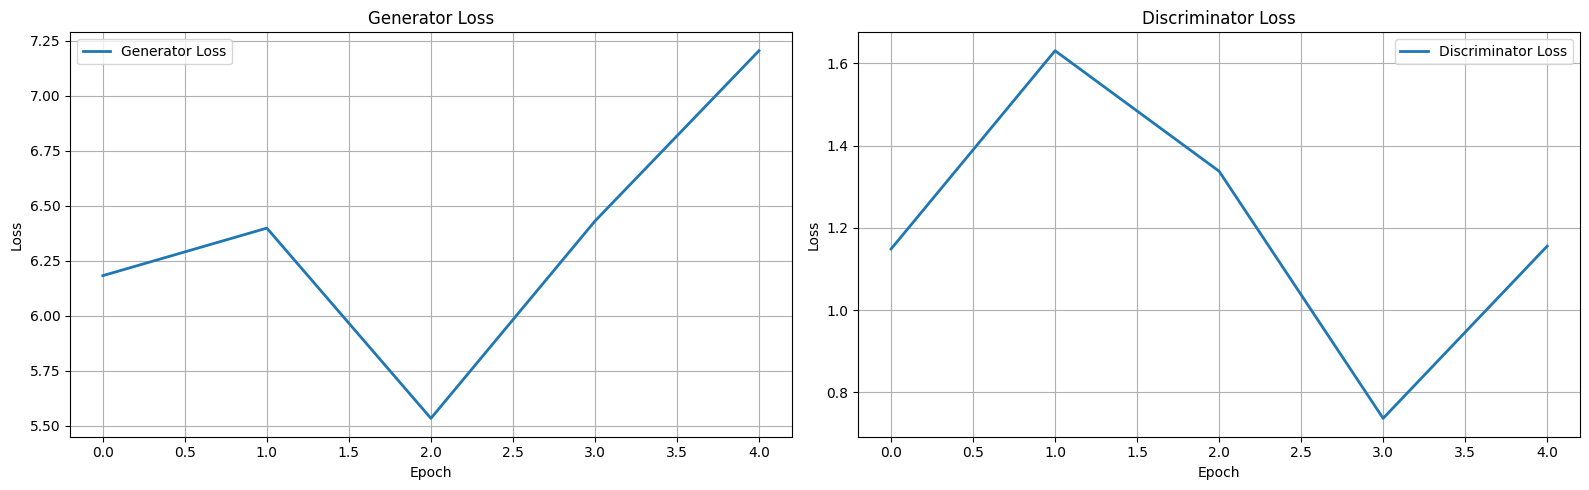

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax1, ax2 = axes

# Plot Generator Loss
ax1.plot(loss_history.g_losses, label="Generator Loss", linewidth=2)
ax1.set_title("Generator Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend()

# Plot Discriminator Loss
ax2.plot(loss_history.d_losses, label="Discriminator Loss", linewidth=2)
ax2.set_title("Discriminator Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

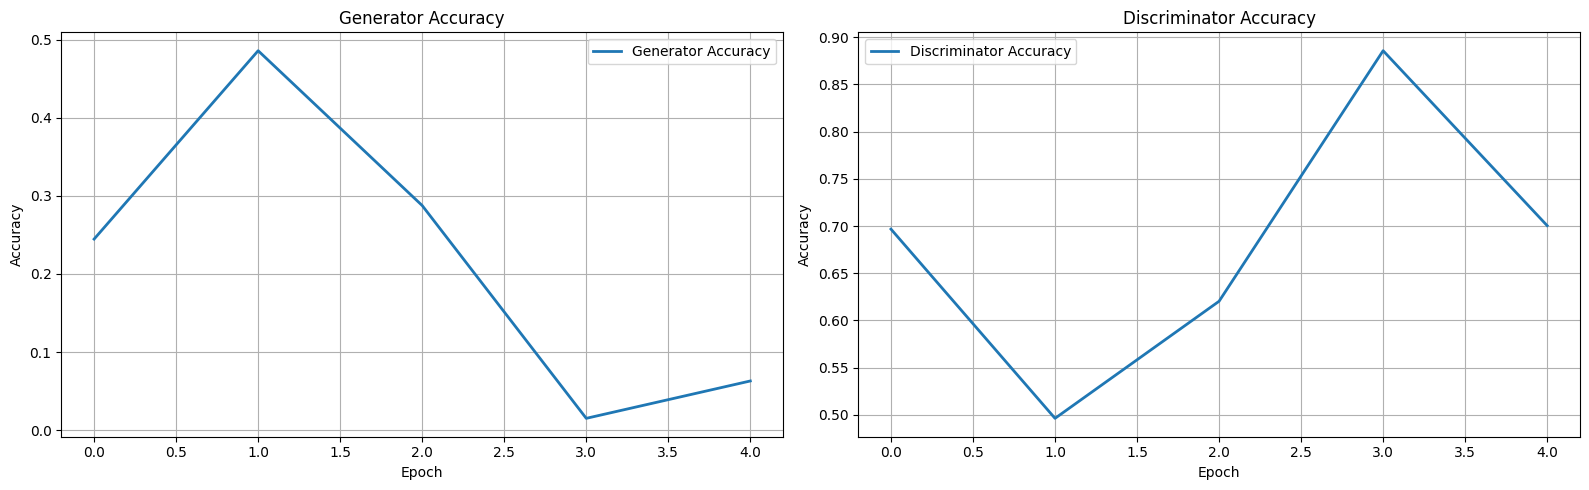

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax1, ax2 = axes

# Generator Accuracy
ax1.plot(loss_history.g_accs, label="Generator Accuracy", linewidth=2)
ax1.set_title("Generator Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.grid(True)
ax1.legend()

# Discriminator Accuracy
ax2.plot(loss_history.d_accs, label="Discriminator Accuracy", linewidth=2)
ax2.set_title("Discriminator Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [21]:
def evaluate_ssim_10_samples(generator, dataset, num_samples=10):
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.subplots_adjust(wspace=0.15, hspace=0.15)

    scores = []

    for i, real_image in enumerate(dataset.take(num_samples)):
        fake_image = generator(real_image, training=False)

        # de-normalize
        real_vis = (real_image[0] + 1) / 2.0
        fake_vis = (fake_image[0] + 1) / 2.0

        # SSIM
        raw_ssim = float(ssim(real_image, fake_image, max_val=2.0).numpy()[0])
        ssim_percent = raw_ssim * 100.0
        scores.append(ssim_percent)

        # Row 1: real
        axes[0, i].imshow(real_vis)
        axes[0, i].set_title("Real", fontsize=12)
        axes[0, i].axis("off")

        # Row 2: fake
        axes[1, i].imshow(fake_vis)
        axes[1, i].set_title(f"SSIM : {ssim_percent:.1f}%", fontsize=12)
        axes[1, i].axis("off")

    plt.show()

    print("Average SSIM :", round(np.mean(scores), 2))
    return scores

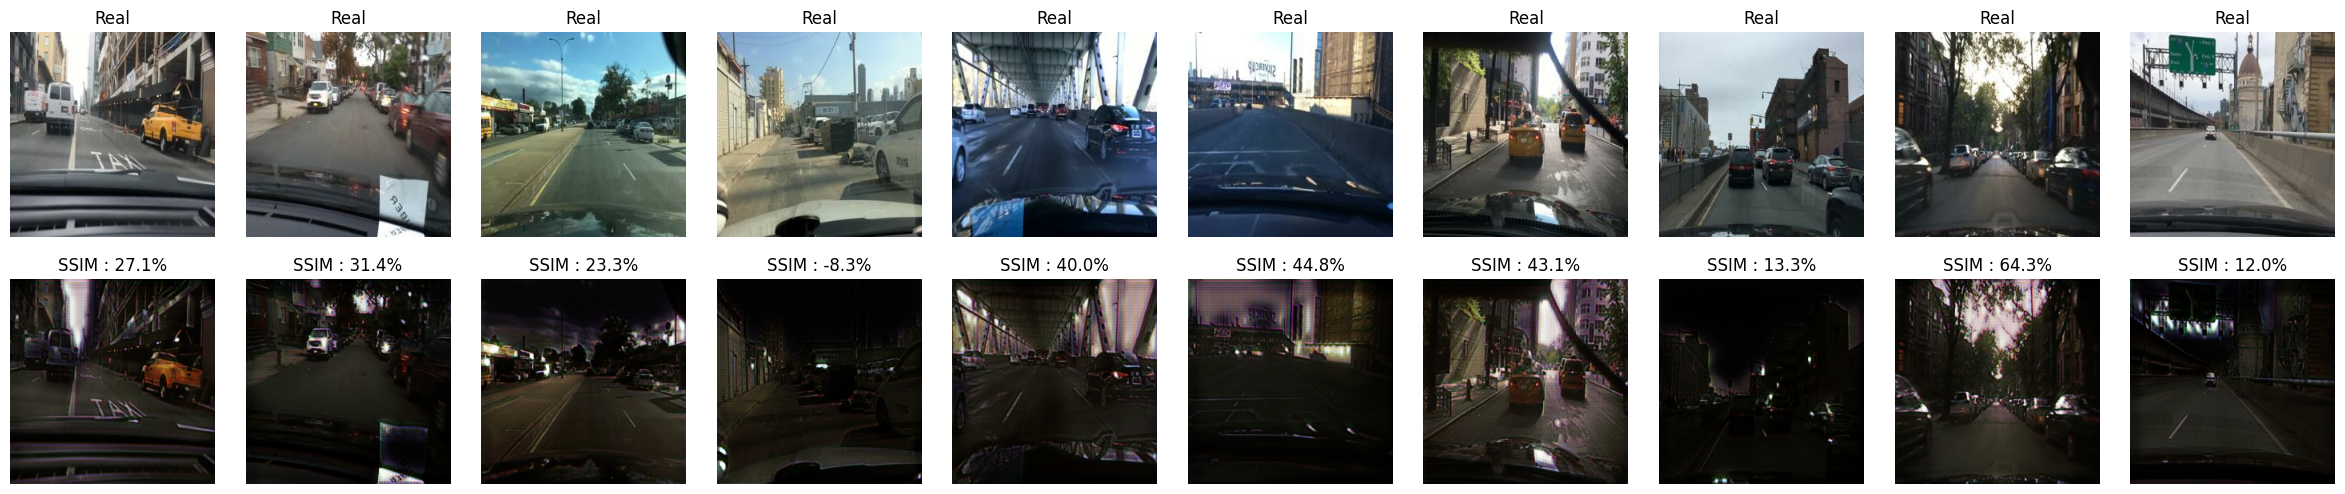

Average SSIM : 29.1


[27.110743522644043,
 31.399616599082947,
 23.26456755399704,
 -8.298677951097488,
 40.00393450260162,
 44.828030467033386,
 43.052420020103455,
 13.312174379825592,
 64.31443095207214,
 12.024561315774918]

In [22]:
evaluate_ssim_10_samples(gan.Gd2n, Day)

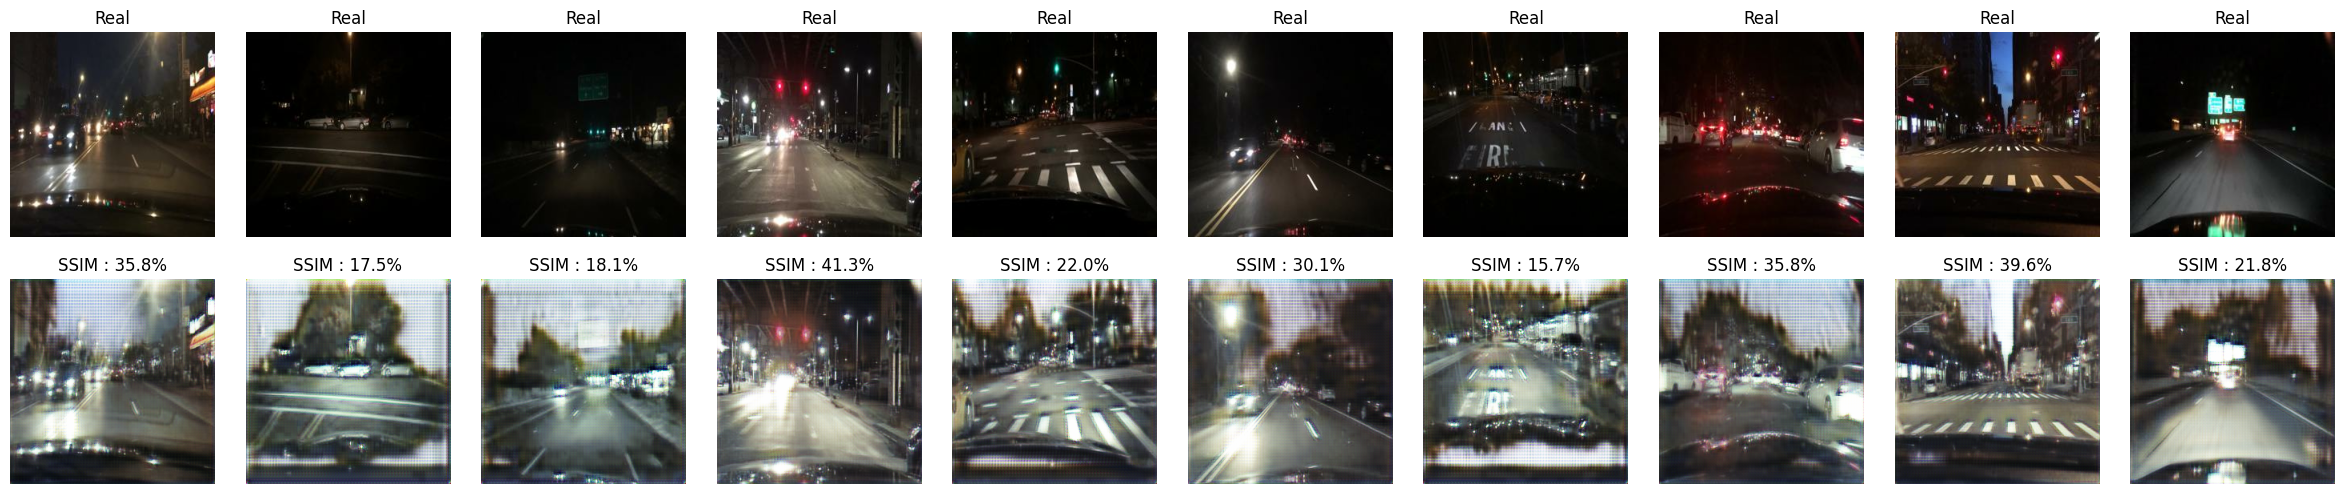

Average SSIM : 27.77


[35.81707179546356,
 17.49831587076187,
 18.098537623882294,
 41.25908315181732,
 21.99426293373108,
 30.08888065814972,
 15.675437450408936,
 35.805392265319824,
 39.60766792297363,
 21.827851235866547]

In [23]:
evaluate_ssim_10_samples(gan.Gn2d, Night)

In [24]:
def evaluate_fid_5_samples(generator, dataset, num_samples=5):
    from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
    import numpy as np
    from scipy.linalg import sqrtm

    # Load Inception once
    inception = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

    # tempat display
    fig, axes = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
    fig.subplots_adjust(wspace=0.15, hspace=0.15)

    # kumpulan fitur untuk FID global
    real_feats_all = []
    fake_feats_all = []

    def prep(img):
        img = (img + 1.0) * 127.5
        img = tf.image.resize(img, (299, 299))
        img = preprocess_input(img)
        return img

    def get_feat(img):
        img = tf.expand_dims(img, 0)
        feat = inception.predict(img, verbose=0)
        return feat[0]

    for i, real_batch in enumerate(dataset.take(num_samples)):
        real_img = real_batch[0]
        fake_img = generator(tf.expand_dims(real_img, 0), training=False)[0]

        # de-normalize for display
        real_vis = (real_img + 1) / 2.0
        fake_vis = (fake_img + 1) / 2.0

        # convert for inception
        real_prep = prep(real_img)
        fake_prep = prep(fake_img)

        # extract features
        real_feat = get_feat(real_prep)
        fake_feat = get_feat(fake_prep)

        real_feats_all.append(real_feat)
        fake_feats_all.append(fake_feat)

        # "per-image FID-like distance" (bukan FID resmi)
        diff = np.sum((real_feat - fake_feat)**2)

        # --- Display real ---
        axes[0, i].imshow(real_vis)
        axes[0, i].set_title("Real")
        axes[0, i].axis("off")

        # --- Display fake ---
        axes[1, i].imshow(fake_vis)
        axes[1, i].set_title(f"DIST: {diff:.1f}")
        axes[1, i].axis("off")

    plt.show()

    # --------------------
    # Hitung FID GLOBAL
    # --------------------
    real_feats_all = np.array(real_feats_all)
    fake_feats_all = np.array(fake_feats_all)

    mu1, sigma1 = real_feats_all.mean(axis=0), np.cov(real_feats_all, rowvar=False)
    mu2, sigma2 = fake_feats_all.mean(axis=0), np.cov(fake_feats_all, rowvar=False)

    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid_score = np.sum((mu1 - mu2)**2) + np.trace(
        sigma1 + sigma2 - 2 * covmean
    )

    print("FID (global, 5 sampel):", fid_score)
    return fid_score

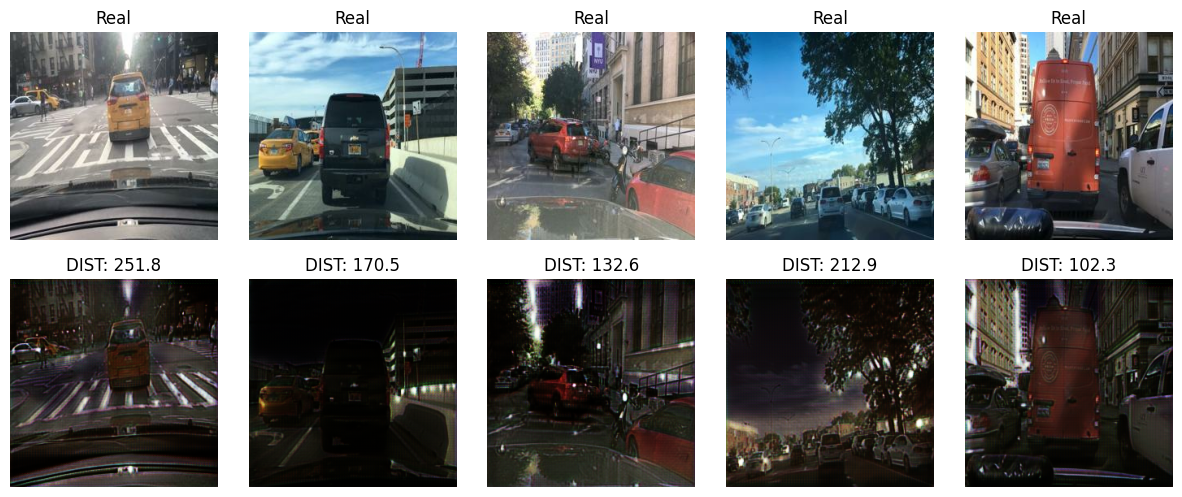

FID (global, 5 sampel): 200.17858176206983


In [25]:
fid_score = evaluate_fid_5_samples(
    generator=gan.Gd2n,
    dataset=Day,
    num_samples=5
)

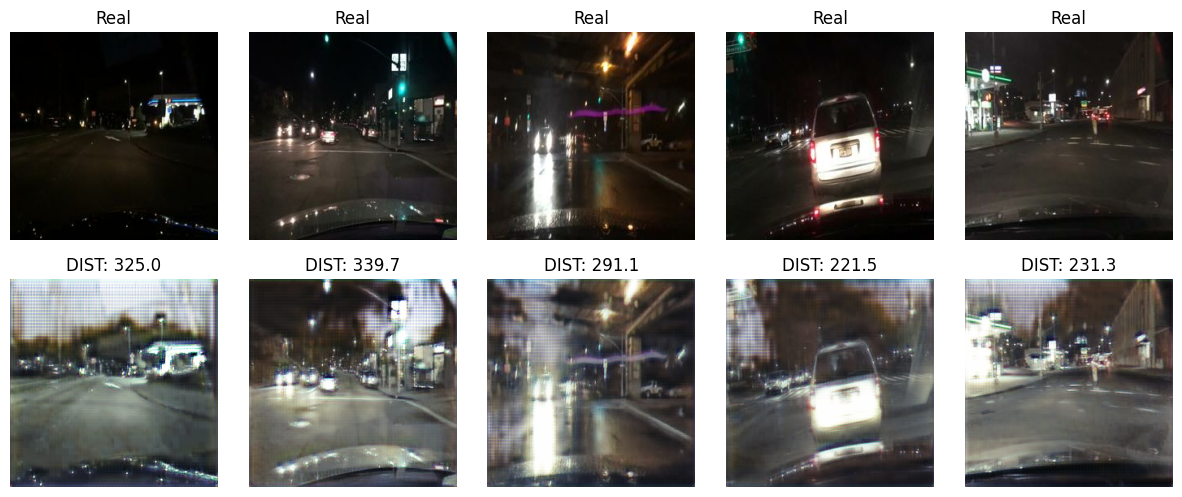

FID (global, 5 sampel): 309.28573879867236


In [26]:
fid_score = evaluate_fid_5_samples(
    generator=gan.Gn2d,
    dataset=Night,
    num_samples=5
)